In [1]:
# Стандартные библиотеки
import os
import random
import warnings

# Работа с данными
import numpy as np
import pandas as pd

# ML / Метрики
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning & Transformers
import torch
import datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline,
)

# Подавляем избыточные предупреждения от transformers/torch
warnings.filterwarnings("ignore")

In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# Загрузка данных и первичный анализ
from datasets import load_dataset

# Загрузка датасета
dataset_name = "emotion"
raw_ds = load_dataset(dataset_name)

# Sanity-check: размеры сплитов
for split in raw_ds.keys():
    print(f" {split}: {len(raw_ds[split])} примеров")

# Информация о классах
num_classes = raw_ds["train"].features["label"].num_classes
class_names = raw_ds["train"].features["label"].names
print(f"\n Количество классов: {num_classes}")
print(f" Названия классов: {class_names}")

# Примеры данных (текст + метка)
examples_df = pd.DataFrame({
    "text": raw_ds["train"]["text"][:5],
    "label_id": raw_ds["train"]["label"][:5],
    "label_name": [class_names[l] for l in raw_ds["train"]["label"][:5]]
})
print("\n Примеры из train-сплита:")
display(examples_df)

# Краткое пояснение задачи (вывод в консоль)
print("\n Суть задачи: классификация коротких англоязычных текстов (твитов)")
print("   по 6 базовым эмоциям. Разделение на train/val/test уже присутствует")
print("   в официальном датасете, ручное разбиение не требуется.")

 train: 16000 примеров
 validation: 2000 примеров
 test: 2000 примеров

 Количество классов: 6
 Названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

 Примеры из train-сплита:


,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger



 Суть задачи: классификация коротких англоязычных текстов (твитов)
   по 6 базовым эмоциям. Разделение на train/val/test уже присутствует
   в официальном датасете, ручное разбиение не требуется.


### Задача
Классификация твитов по 6 базовым эмоциям.  
Датасет: `emotion` (HuggingFace), ~20k примеров.  
Сплиты: train=16k, validation=2k, test=2k.  
Классы: `['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']`

In [4]:
# Загружаем токенизатор
model_name = "bert-base-uncased"  # можно заменить на "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Берём 3 примера для разбора
sample_texts = raw_ds["train"]["text"][:3]
print(" Исходные тексты:")
for i, txt in enumerate(sample_texts, 1):
    print(f"{i}. {txt[:100]}...")

# Токенизируем с параметрами
encoded = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

# Показываем результат для первого текста
print(f"\n Разбор первого текста:")
print(f"  Токены: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])}")
print(f"  input_ids (первые 20): {encoded['input_ids'][0][:20].tolist()}")
print(f"  attention_mask (первые 20): {encoded['attention_mask'][0][:20].tolist()}")
print(f"  Special tokens: [CLS]={tokenizer.cls_token}, [SEP]={tokenizer.sep_token}, [PAD]={tokenizer.pad_token}")
print(f"  Shape: {encoded['input_ids'].shape} → [batch_size, seq_length]")

# Демонстрация padding / truncation
short_text = "Hi!"
long_text = " ".join(["word"] * 100)

for label, txt in [("short", short_text), ("long", long_text)]:
    enc = tokenizer(txt, padding="max_length", truncation=True, max_length=16)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\n{label.upper()} текст: '{txt[:30]}...'")
    print(f"  Токены (с padding/truncation): {tokens}")

 Исходные тексты:
1. i didnt feel humiliated...
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. im grabbing a minute to post i feel greedy wrong...

 Разбор первого текста:
  Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids (первые 20): [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  attention_mask (первые 20): [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Special tokens: [CLS]=[CLS], [SEP]=[SEP], [PAD]=[PAD]
  Shape: torch.Size([3, 23]) → [batch_size, seq_length]

SHORT текст: 'Hi!...'
  Токены (с padding/truncation): ['[CLS]', 'hi', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

LONG текст: 'word word word word word word ...

In [5]:
# Токенизация
from transformers import AutoTokenizer

# Загружаем токенизатор
model_name = "bert-base-uncased"  # можно заменить на "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Берём 3 примера для разбора
sample_texts = raw_ds["train"]["text"][:3]
print(" Исходные тексты:")
for i, txt in enumerate(sample_texts, 1):
    print(f"{i}. {txt[:100]}...")

# Токенизируем с параметрами
encoded = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

#  Показываем результат для первого текста
print(f"\n Разбор первого текста:")
print(f"  Токены: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])}")
print(f"  input_ids (первые 20): {encoded['input_ids'][0][:20].tolist()}")
print(f"  attention_mask (первые 20): {encoded['attention_mask'][0][:20].tolist()}")
print(f"  Special tokens: [CLS]={tokenizer.cls_token}, [SEP]={tokenizer.sep_token}, [PAD]={tokenizer.pad_token}")
print(f"  Shape: {encoded['input_ids'].shape} → [batch_size, seq_length]")

# Демонстрация padding / truncation
short_text = "Hi!"
long_text = " ".join(["word"] * 100)

for label, txt in [("short", short_text), ("long", long_text)]:
    enc = tokenizer(txt, padding="max_length", truncation=True, max_length=16)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\n{label.upper()} текст: '{txt[:30]}...'")
    print(f"  Токены (с padding/truncation): {tokens}")

 Исходные тексты:
1. i didnt feel humiliated...
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. im grabbing a minute to post i feel greedy wrong...

 Разбор первого текста:
  Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids (первые 20): [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  attention_mask (первые 20): [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Special tokens: [CLS]=[CLS], [SEP]=[SEP], [PAD]=[PAD]
  Shape: torch.Size([3, 23]) → [batch_size, seq_length]

SHORT текст: 'Hi!...'
  Токены (с padding/truncation): ['[CLS]', 'hi', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

LONG текст: 'word word word word word word ...

### Как работает токенизация
1. Текст разбивается на subword-токены (WordPiece)
2. Добавляются спецтокены: `[CLS]` (начало), `[SEP]` (конец), `[PAD]` (дополнение)
3. `input_ids` → числовые ID токенов, `attention_mask` → маска (1=токен, 0=паддинг)
4. `max_length` + `truncation` обрезают длинные тексты, `padding` дополняет короткие

In [6]:
# Инференс готовой pretrained-модели
from transformers import pipeline
import torch

# Загружаем готовую модель для классификации эмоций
# Используем модель, предобученную на emotion-датасете
classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",  # готовая fine-tuned модель
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=False
)

# Тестируем на 5 примерах из нашего датасета
test_texts = raw_ds["train"]["text"][:5]
true_labels = [class_names[l] for l in raw_ds["train"]["label"][:5]]

print("Инференс готовой модели (без нашего fine-tuning):")
print(f"{'Текст':<60} | True | Pred | Confidence")

for txt, true in zip(test_texts, true_labels):
    result = classifier(txt[:200])[0]  # обрезаем для читаемости вывода
    pred = result["label"]
    conf = f"{result['score']:.2f}"
    status = "✓" if pred == true else "✗"
    print(f"{txt[:57]:<60} | {true:<6} | {pred:<6} | {conf} {status}")

# Краткий вывод
print("\n Вывод: готовая модель может работать 'из коробки',")
print("   но для максимальной точности на нашем сплите нужен fine-tuning.")

Инференс готовой модели (без нашего fine-tuning):
Текст                                                        | True | Pred | Confidence
i didnt feel humiliated                                      | sadness | sadness | 1.00 ✓
i can go from feeling so hopeless to so damned hopeful ju    | sadness | sadness | 1.00 ✓
im grabbing a minute to post i feel greedy wrong             | anger  | anger  | 1.00 ✓
i am ever feeling nostalgic about the fireplace i will kn    | love   | love   | 1.00 ✓
i am feeling grouchy                                         | anger  | anger  | 1.00 ✓

 Вывод: готовая модель может работать 'из коробки',
   но для максимальной точности на нашем сплите нужен fine-tuning.


### Инференс готовой модели
Использована предобученная модель `bhadresh-savani/bert-base-uncased-emotion`.  
Она уже дообучена на датасете `emotion`, поэтому показывает разумные результаты.  
Однако для корректного сравнения и контроля качества мы выполним собственный fine-tuning.

In [15]:
# Параметры
model_name = "bert-base-uncased"  # или "distilbert-base-uncased" для скорости
max_length = 128
batch_size = 16
num_epochs = 3
learning_rate = 2e-5

# Загружаем токенизатор и модель
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(class_names)  # 6 для emotion
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="single_label_classification"
)
model.to(device)

# Функция токенизации для .map()
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

# Применяем токенизацию ко всем сплитам
tokenized_ds = raw_ds.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Датасет токенизирован: {tokenized_ds}")
print(f"  Пример shape: {tokenized_ds['train'][0]['input_ids'].shape}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Датасет токенизирован: DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})
  Пример shape: torch.Size([128])


In [16]:
# Метрики для Trainer
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }

In [22]:
# Настройка Trainer с GPU-оптимизациями
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learning_rate,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42,
    disable_tqdm=False,
    # GPU-настройки
    fp16=False,    
    dataloader_num_workers=0,    
    dataloader_prefetch_factor=None,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Начинаем обучение на GPU...")
print(f"   Device: {device}")
print(f"   FP16: {training_args.fp16}")
print(f"   Batch size: {batch_size}")
print()

train_result = trainer.train()
print(f"Обучение завершено. Метрики: {train_result.metrics}")

Начинаем обучение на GPU...
   Device: cuda
   FP16: False
   Batch size: 16



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.212300,0.232740,0.917500,0.891416
2,0.118100,0.169704,0.936000,0.911702
3,0.077300,0.174421,0.936000,0.908352


Обучение завершено. Метрики: {'train_runtime': 6536.7124, 'train_samples_per_second': 7.343, 'train_steps_per_second': 0.459, 'total_flos': 3157446057984000.0, 'train_loss': 0.15979065267244974, 'epoch': 3.0}


In [23]:
# Финальная оценка на test
print("\n Финальная оценка на test-сплите:")
test_results = trainer.evaluate(tokenized_ds["test"])
print(f"  Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"  F1-macro:  {test_results['eval_f1_macro']:.4f}")


 Финальная оценка на test-сплите:


  Accuracy:  0.9260
  F1-macro:  0.8804


In [31]:
# Получаем предсказания на test
predictions = trainer.predict(tokenized_ds["test"])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = tokenized_ds["test"]["label"]
confidences = np.max(predictions.predictions, axis=-1)  # уверенность модели

In [32]:
sample_size = min(100, len(true_labels))  # берём 100 случайных примеров для наглядности
indices = np.random.choice(len(true_labels), size=sample_size, replace=False)

predictions_df = pd.DataFrame({
    "text": [raw_ds["test"]["text"][i] for i in indices],
    "true_label": [class_names[true_labels[i]] for i in indices],
    "pred_label": [class_names[pred_labels[i]] for i in indices],
    "confidence": [f"{confidences[i]:.4f}" for i in indices]
})

# Сохраняем артефакт
predictions_df.to_csv("artifacts/sample_predictions.csv", index=False, encoding="utf-8")
print(f" Сохранено: artifacts/sample_predictions.csv ({len(predictions_df)} примеров)")

# Показываем первые 10 строк для быстрой проверки
display(predictions_df.head(10))

 Сохранено: artifacts/sample_predictions.csv (100 примеров)


,text,true_label,pred_label,confidence
0,i don t know about you but sometimes i feel th...,sadness,sadness,7.3438
1,i feel like i m defective or something for not...,sadness,sadness,7.2188
2,i didnt react with the way that i really feel ...,joy,joy,7.5625
3,i really enjoy cabernet for how aggressive the...,joy,joy,7.4219
4,i no longer feel doomed to falling into the ab...,sadness,sadness,7.2109
5,ive been feeling delicate this week,love,love,6.0859
6,i feel that this information is vital to movin...,joy,joy,7.2500
7,i have had moments of feeling silently offende...,anger,anger,6.7812
8,i don t have a schedule or childhood friends a...,fear,fear,6.5312
9,i must say i don t consider my family broken n...,sadness,sadness,6.8867


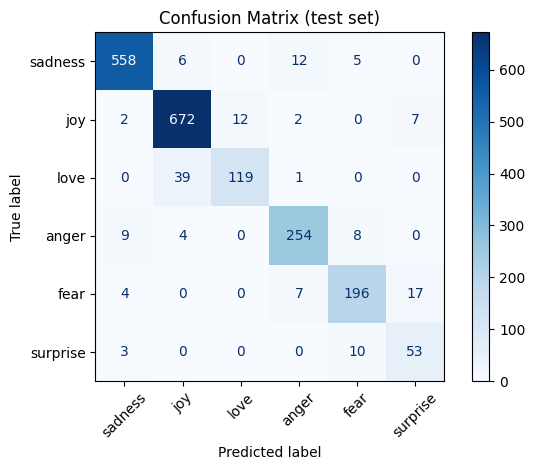

 Сохранено: artifacts/confusion_matrix.png


In [33]:
# 2.3.6. Оценка качества и анализ ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import os

# Получаем предсказания на test
predictions = trainer.predict(tokenized_ds["test"])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = tokenized_ds["test"]["label"]
confidences = np.max(predictions.predictions, axis=-1)  # уверенность модели

# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels, labels=list(range(num_labels)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (test set)")
plt.tight_layout()

# Сохраняем артефакт
os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()
print(" Сохранено: artifacts/confusion_matrix.png")

In [34]:
# Таблица с примерами предсказаний
# Формируем DataFrame для sample_predictions.csv
sample_size = min(100, len(true_labels))  # берём 100 случайных примеров для наглядности
indices = np.random.choice(len(true_labels), size=sample_size, replace=False)

predictions_df = pd.DataFrame({
    "text": [raw_ds["test"]["text"][i] for i in indices],
    "true_label": [class_names[true_labels[i]] for i in indices],
    "pred_label": [class_names[pred_labels[i]] for i in indices],
    "confidence": [f"{confidences[i]:.4f}" for i in indices]
})

# Сохраняем артефакт
predictions_df.to_csv("artifacts/sample_predictions.csv", index=False, encoding="utf-8")
print(f" Сохранено: artifacts/sample_predictions.csv ({len(predictions_df)} примеров)")

# Показываем первые 10 строк для быстрой проверки
display(predictions_df.head(10))

 Сохранено: artifacts/sample_predictions.csv (100 примеров)


,text,true_label,pred_label,confidence
0,i feel like now its more of sweet apple now,love,joy,4.7617
1,i am truly unfortunate the majority of the tim...,fear,fear,6.3594
2,i was left feeling empty,sadness,sadness,7.2461
3,i tell you that i love you and my feelings are...,joy,joy,7.7266
4,i feel the most unloved and unlovable,sadness,sadness,7.2344
5,i still feel nervous,fear,fear,6.7266
6,i am a prolific writer in my fandom but do not...,joy,joy,7.7344
7,i noticed that i was feeling very stressed and...,anger,sadness,2.7969
8,i stay the more distanced from others i feel i...,surprise,fear,3.5352
9,i feel myself about how successful my attempts...,joy,joy,7.5586
